# VisualAstro Quickstart Tutorial

visualastro is a plotting library designed for astrophysical research and making publication ready visualizations. The library is designed for ease of use when visualizing data, and customizability. The library acts as an extension of matplotlib, numpy, and astropy, to minimize the learning curve of using visualastro. As such, the syntax of visualastro matches that of the parent libraries as much as possible.

In [1]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import visualastro as va

The core idea of visualastro is to provide wrapper functions of existing matplotlib plotting functions which extend its capabilities. Each visualastro plotting function takes in the input data, the `matplotlib.axes.Axes` instance, and any `kwargs` to be passed along.

To start, we will define some data:

In [2]:
x, y, z = va.blob(N=10000)
t = np.linspace(-6, 6, 50)
sin = np.sin(t)

### Creating Plots

Here is the most basic way of using visualastro. We create a matplotlib `Figure` and `Axes` instance, and pass the data and `Axes` to the visualastro plotting function of choice.

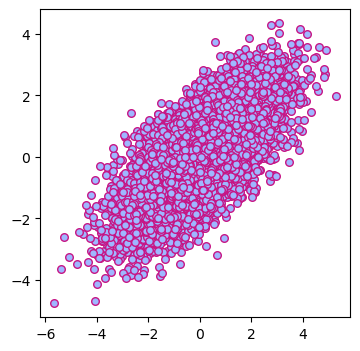

In [3]:
va.scatter(x, y, ec='mediumvioletred', s=30, figsize=(4,4))

As you can see, this is mostly identical to a native `ax.scatter(x, y)` call. Where `va.scatter` shines is the ability to pass in more than one dataset to be plotted. `visualastro` will loop over each pair of inputs and plot them on the `Axes` instance. This behavior is even supported for common kwargs like `color`, `alpha`,  `marker`, `s` (marker size), `linestyle` and `linewidth` (for `va.plot`), etc... `visualastro` loops over these inputs using cyclic indexing, meaning the user does not need to worry about the length of each input matching (ie. if three data inputs are provided but only two markerstyles are specified, the third plotting input will use the markerstyle of the first input).

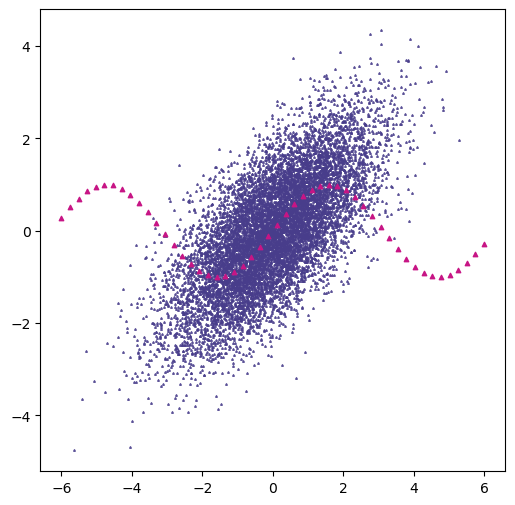

In [4]:
# notice how 2 sizes and colors are specified, but only one markerstyle is set. visualastro is flexible!
va.scatter([x, t], [y, sin], s=[1, 10], marker='^', color=['darkslateblue', 'mediumvioletred'])
plt.show()

visualastro can also broadcast your $x$ data for convenience! This notation only works to simplify the following case:

$(x_{1}, x_{2}, ..., x_{n}),  (y_{1}, y_{2}, ..., y_{n}) → x, (y_{1}, y_{2}, ..., y_{n})$ where $x_{1}, x_{2}, ... x_{n}$ all have the same shape.

Note that here we must pass in `ax` to specify which subplot to map each `va.scatter` call onto!

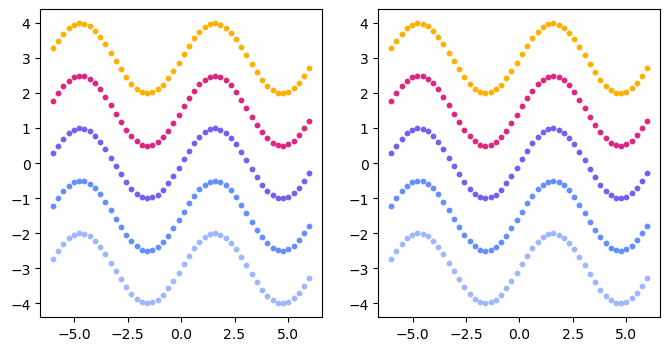

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

va.scatter([t, t, t, t, t], [sin-3, sin-1.5, sin, sin+1.5, sin+3], ax=ax[0])

# this notation is identical to the above notation !
va.scatter(t, [sin-3, sin-1.5, sin, sin+1.5, sin+3], ax=ax[1])

plt.show()

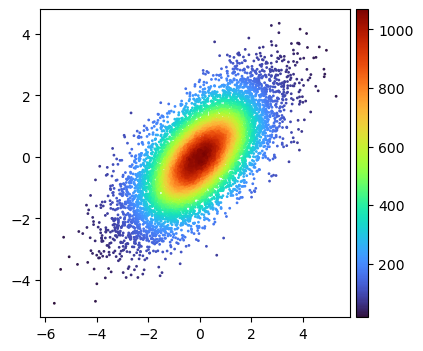

In [6]:
# compute number density
nd2d = va.number_density(np.vstack([x, y]).T, 2000)

va.scatter(x, y, c=nd2d, s=1, figsize=(4,4))
plt.show()

### Setting the Plot Style

Upon import, visualastro will register all of its styles with matplotlib. To use them, simply call `plt.style.use('stylename')`.

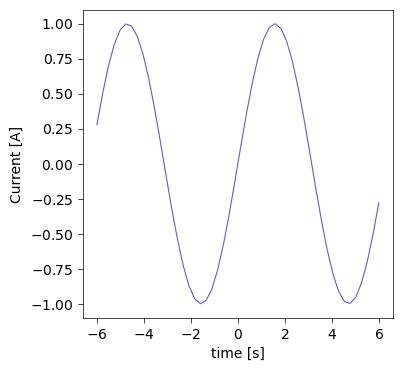

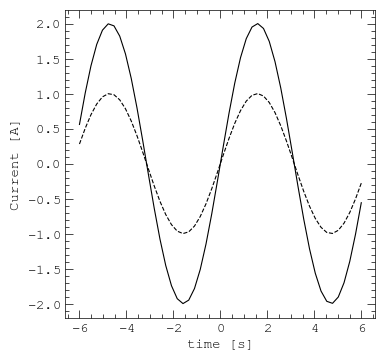

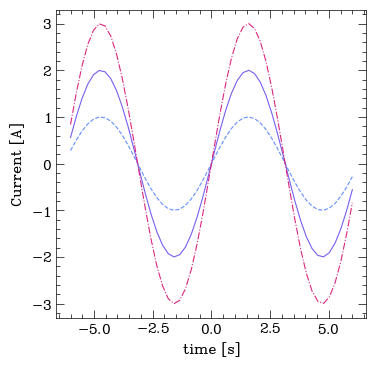

In [7]:
plt.style.use(['minimal'])
va.plot(t, sin, figsize=(4,4), color='slateblue', xlabel='time [s]', ylabel='Current [A]')
plt.show()

with plt.style.context(['full', 'courier-new']):
    va.plot(t, [sin, sin*2], figsize=(4,4), color='k', ls=['--', '-'], xlabel='time [s]', ylabel='Current [A]')
    plt.show()

plt.style.use(['full', 'hershey'])
va.plot(t, [sin, sin*2, sin*3], figsize=(4,4), color='ibm', ls=['--', '-', '-.'], xlabel='time [s]', ylabel='Current [A]')
plt.show()

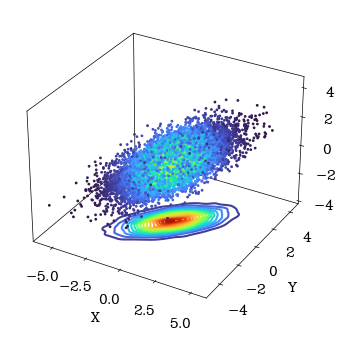

In [8]:
nd3d = va.number_density(np.vstack([x,y,z]).T, 2000)
va.scatter3D(x, y, z, figsize=(4,4), s=1, axis_style='panel', plot_contours='z', c=nd3d)

### The Config Class

A core feature of visualastro is the ability to change function default values at runtime through the configuration class. `va.config` is a `dataclass` whose values are able to be changed dynamically. This allows updating the values of global variables in visualastro at runtime without restarting the kernel.

For example, in all the above examples, the figsize was manually set to `figsize=(4,4)`. To avoid this repetition, we can set the figsize through the config class.

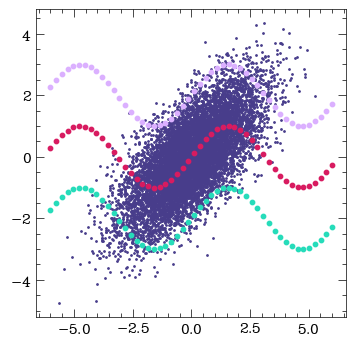

In [9]:
va.config.figsize = (4,4)
va.config.style = 'smplot' # set plot style
va.config.color = ['#483d8b', '#d81b60', '#dbb0ff', '#26dcba', '#7d7ff3', '#cfe23c'] # set the plot color cycle
va.config.scatter_size = [1, 10, 10, 10]

# now if we recreate our previous plot
scatters = va.scatter([x, t, t, t], [y, sin, sin+2, sin-2])

In [10]:
# va.scatter returns a list of each scatter PathCollection
scatters

We can also revert to the original default values by running `va.config.reset()`

### Figure creation

visualastro also has convenience functions for generating figures!

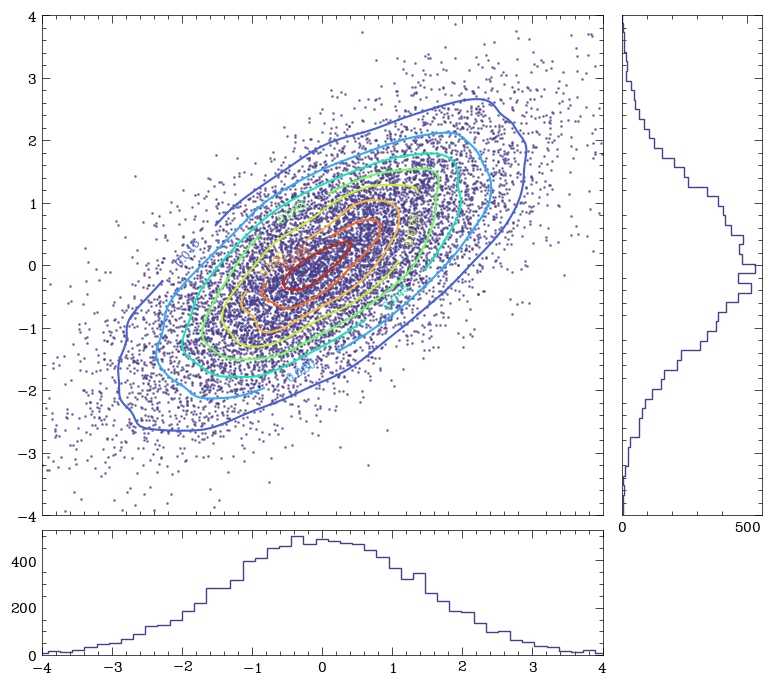

In [11]:
# as you can see, you can mix and match native matplotlib functions with visualastro functions. va is an extension!

fig, ax = va.tripanel_figure(sharex=True, sharey=True)

ax[0].scatter(x, y, s=1, color='darkslateblue', alpha=0.6)
ax[1].hist(x, histtype='step', color='darkslateblue', bins='auto')
ax[2].hist(y, histtype='step', color='darkslateblue', bins='auto', orientation='horizontal')

va.contour_kde(x, y, ax=ax[0], levels=10, cslabel=True) # add contours using kde density estimation

ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)

plt.show()

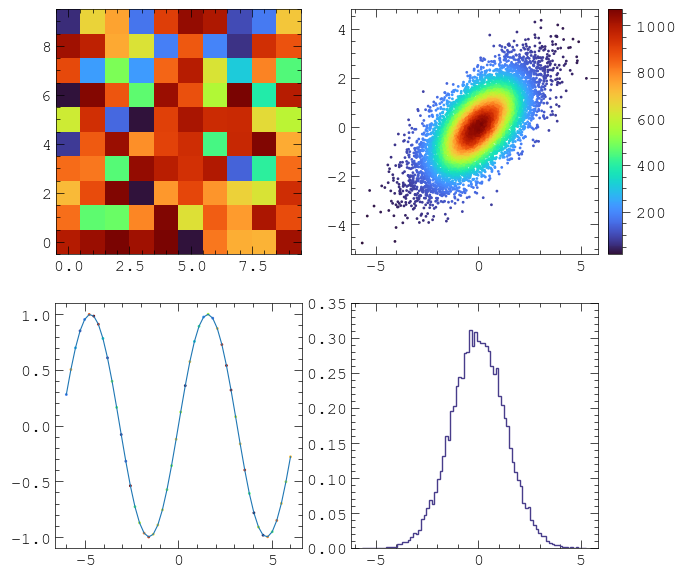

In [12]:
with plt.style.context('courier-new'):
    fig, ax = va.gridspec(nrows=2, ncols=2, figsize=(7,7))
    
    va.imshow(np.random.rand(10,10), ax=ax[0], colorbar=False, cmap='turbo')
    
    va.scatter(x, y, ax=ax[1], c=nd2d, cbar_width=0.02, s=1)

    va.scatter_fit(t, sin, deg=20, ax=ax[2], c=np.random.rand(len(t)), colorbar=False)

    va.hist(np.vstack([x, y]).T, ax=ax[3], xlog=False, ylog=False, ylim=(0, 0.35))
    
    plt.show()

### Colorsets

On top of the native `ColorTypes` recognized by matplotlib (hex colors, rgb/rgba tuples, named colors), visualastro recognizes a set of packaged colorsets. You can view them at any time using `va.help`.

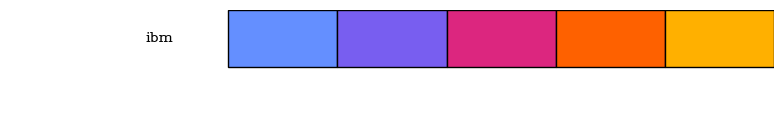

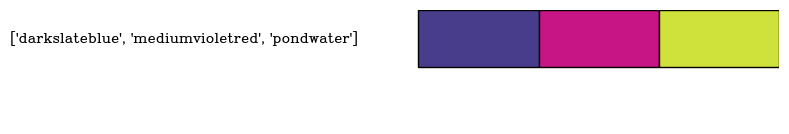

In [13]:
va.help.color('ibm', show_color_name=True)

va.help.color(['darkslateblue', 'mediumvioletred', 'pondwater'], show_color_name=True)

The actual color values can be retrieved using `va.get_colors`, and the colorsets are valid inputs to the `color` argument of any visualastro plotting function.

In [14]:
colors = va.get_colors('cardstock_light')
colors

['#9fd8fb', '#aed75b', '#bddcbd', '#fb998e', '#e177ab', '#cdcdcd']

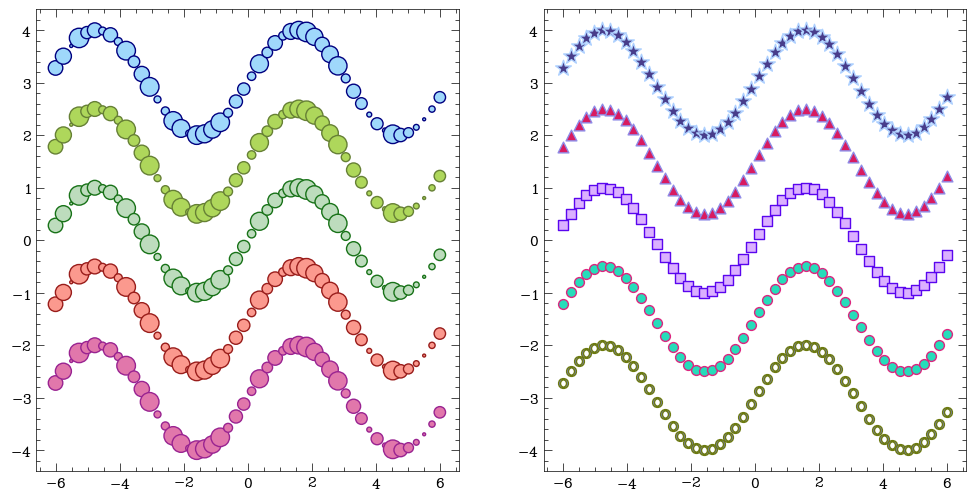

In [15]:
va.config.scatter_size = 10
fig, ax = va.gridspec()
va.scatter(
    t, [sin+3, sin+1.5, sin, sin-1.5, sin-3], 
    ax=ax[0],
    color=colors,
    edgecolor='cardstock_dark',
    s=np.random.rand(len(t))*200
)

va.scatter(
    t, [sin+3, sin+1.5, sin, sin-1.5, sin-3],
    ax=ax[1],
    color='MSG', 
    ec='astro_contrast', 
    m=['*', '^', 's', 'o', '$o$'],
    s=[140, 60, 50, 50, 50]
)

### Cycling Through the Color Cycle
You can also change the ordering of any of the cycles with `va.config.color

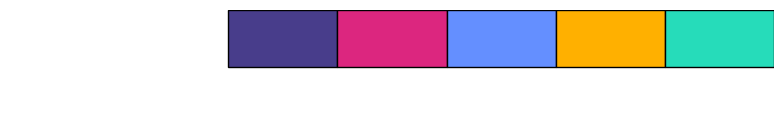

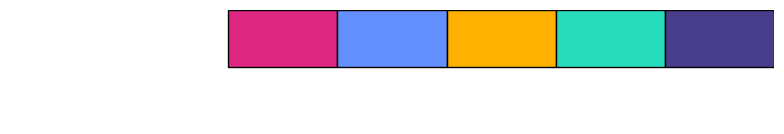

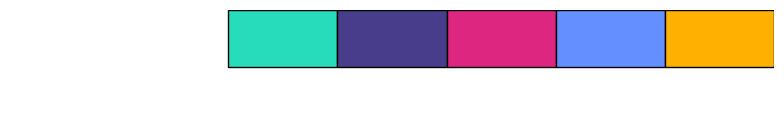

In [16]:
# the index is cyclic so you do not need to worry about indexing errors
va.config.color_cycle_idx = 0
va.help.color('va')
va.config.color_cycle_idx = 1
va.help.color('va')
va.config.color_cycle_idx = 4
va.help.color('va')

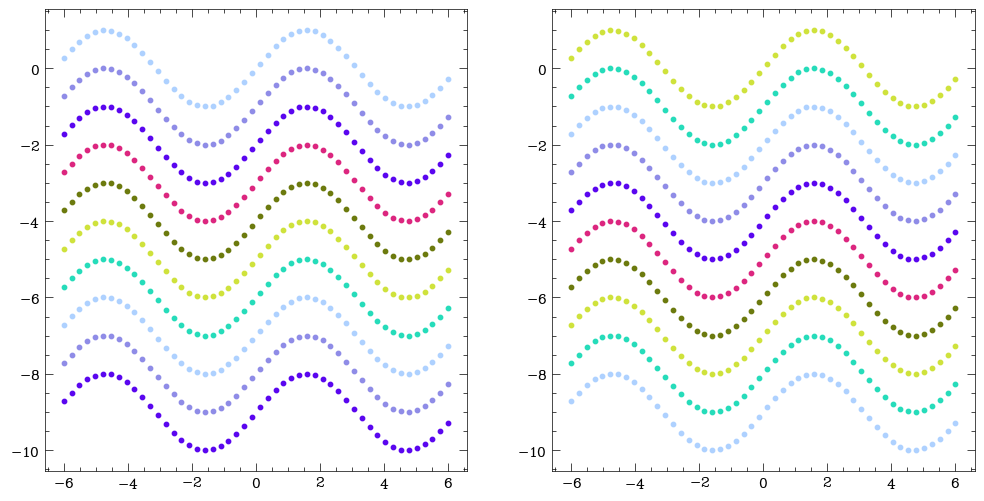

In [17]:
# change the start of the cycle! 
fig, axs = va.gridspec()
cycle_idx = [0, 5]

for i, ax in enumerate(axs):
    va.config.color_cycle_idx = cycle_idx[i]
    va.scatter(t, [sin - i for i in range(10)], ax=ax, color='astro_contrast')
plt.show()

#### All Colorsets

We can view all visualastro supported colorsets with `va.help.color()`

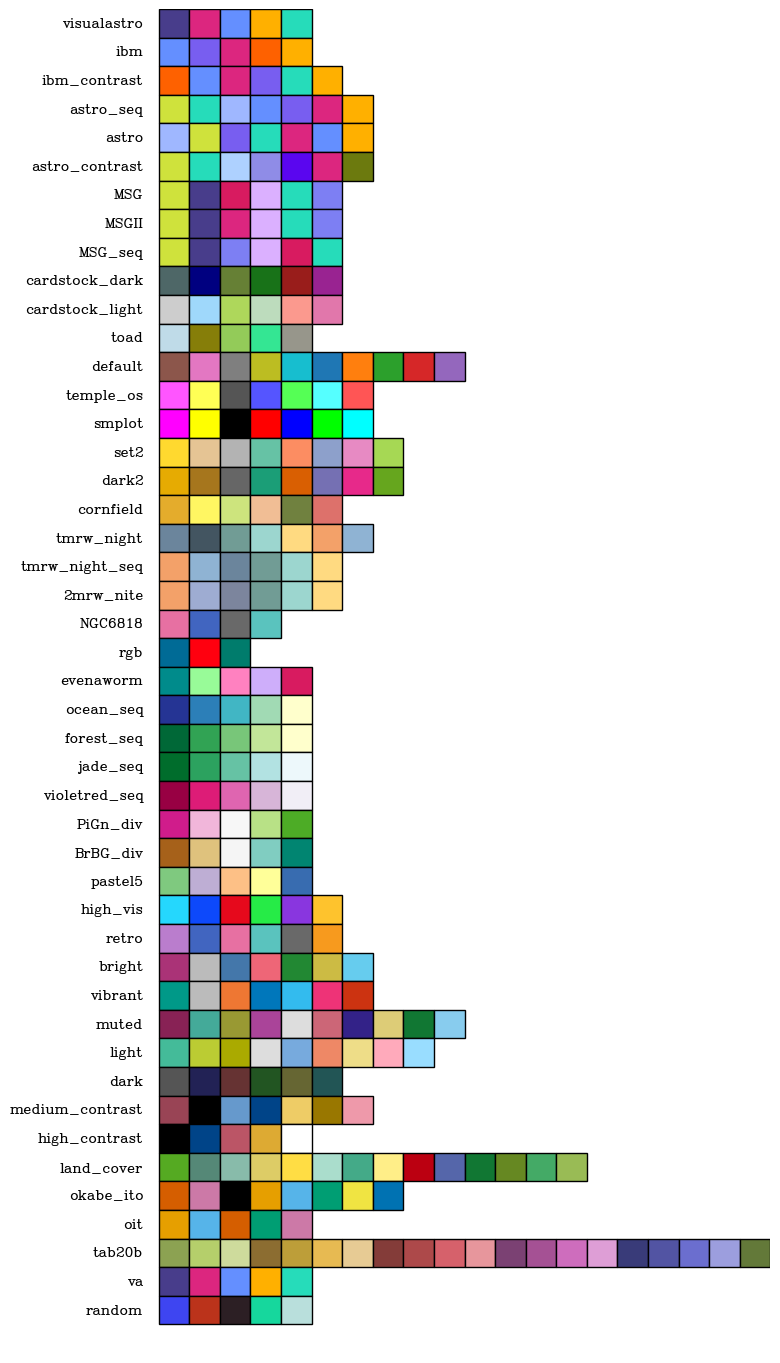

In [18]:
va.help.color()

### Named Colors

We can plot the named colors using `va.help` as well:

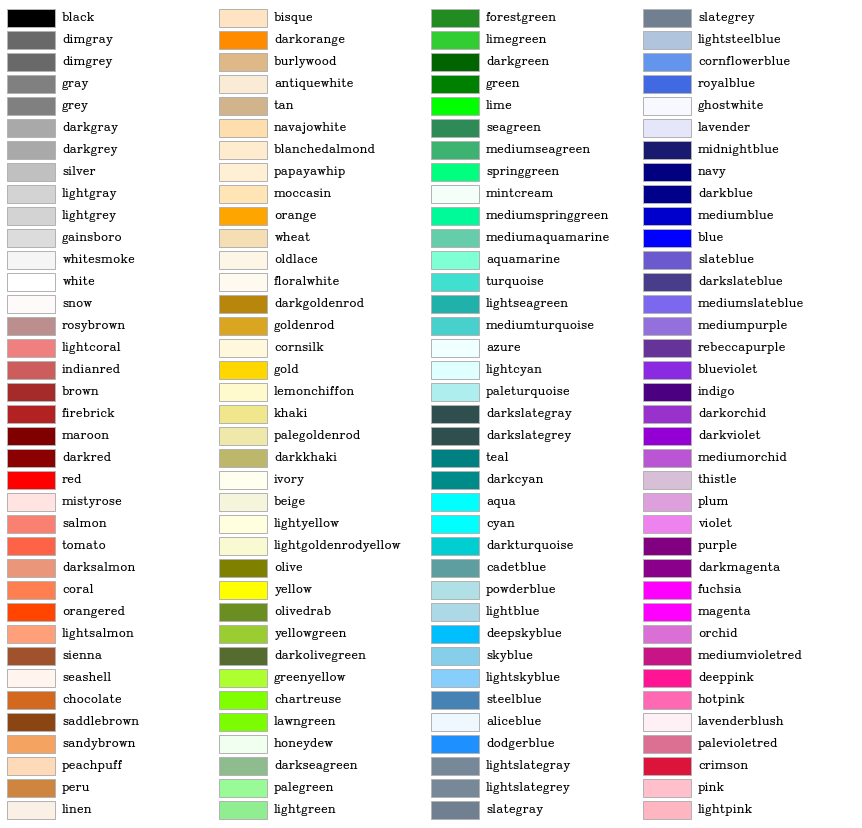

In [19]:
va.help.named_colors()

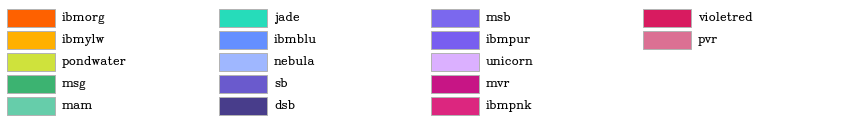

In [20]:
# visualastro named colors
va.help.va_colors()

All colors displayed here are recognizable by matplotlib under the name space 'xkcd:colorname'. 
Visualastro will also recognize the colors if 'xkcd:' is dropped.


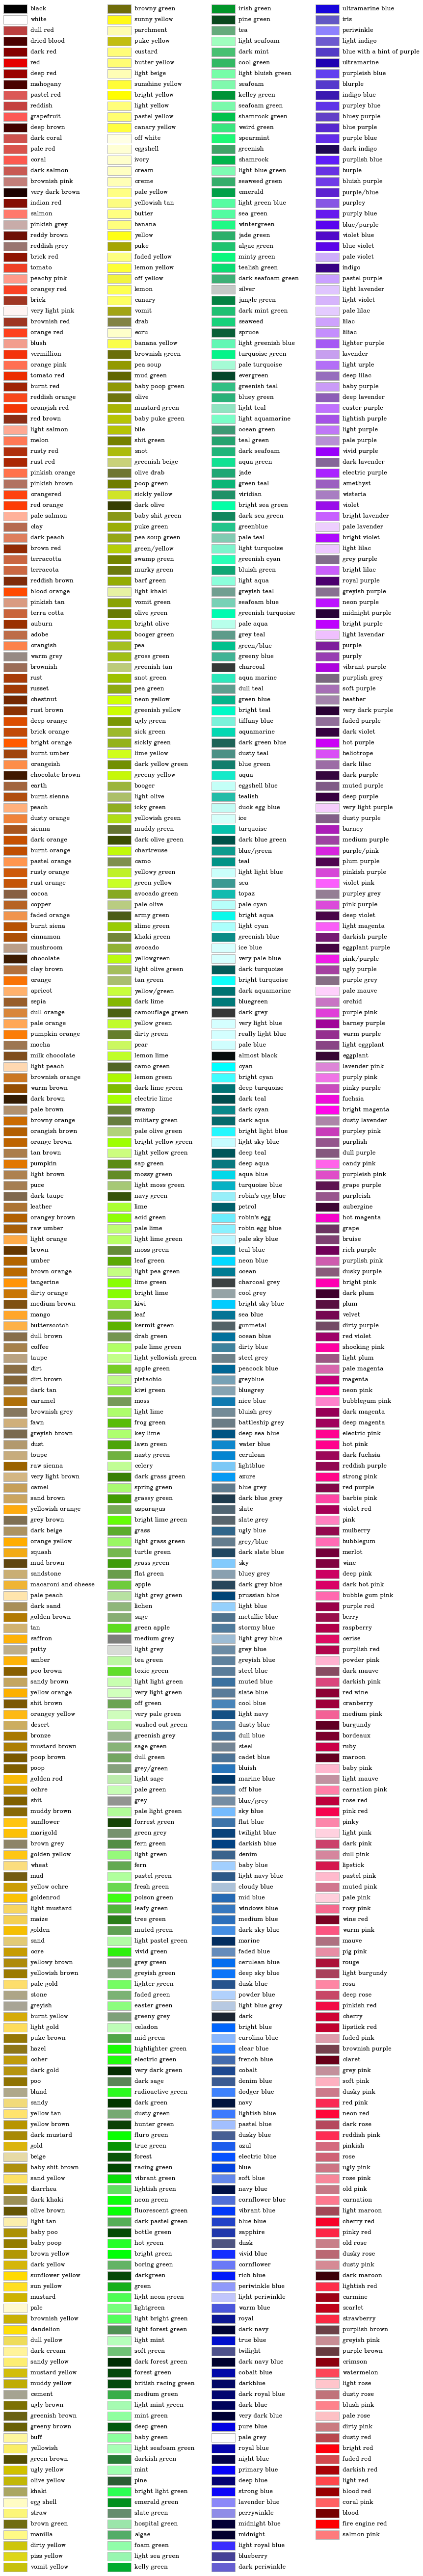

In [21]:
# we can also see the xkcd colors. visualastro also recognizes these colors (without the need to specify 'xkcd:' before the colorname)
va.help.xkcd_colors()

In [22]:
# as you can see, visualastro recognizes a large range of colortypes!
print('matplotlib named color:', va.get_colors('darkslateblue'))
print('visualastro named color:', va.get_colors('dsb'))
print('visualastro colorset:', va.get_colors('astro'))
print('xkcd:', va.get_colors('xkcd:pea soup'))
print('xkcd alias:', va.get_colors('pea soup'))

matplotlib named color: ['#483d8b']
visualastro named color: ['#483d8b']
visualastro colorset: ['#9fb7ff', '#cfe23c', '#785ef0', '#26dcba', '#dc267f', '#648fff', '#ffb000']
xkcd: ['#929901']
xkcd alias: ['#929901']


### More Sample Plots

In [23]:
va.config.reset()

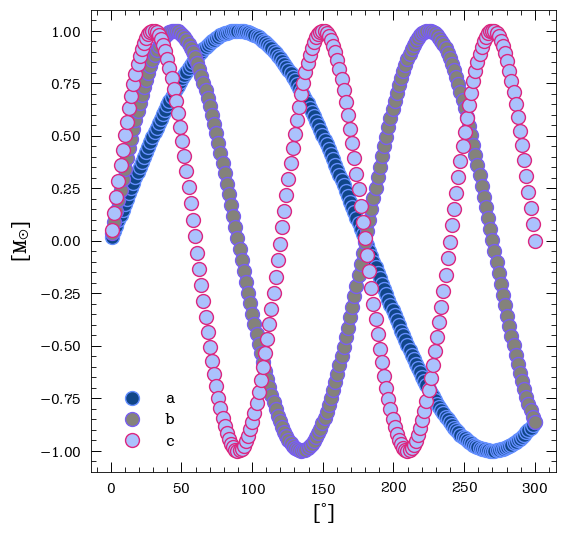

In [24]:
va.help.scatter()

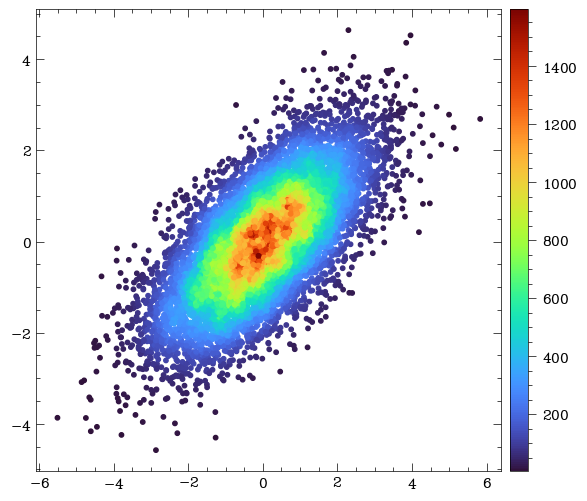

In [31]:
va.help.scatter()

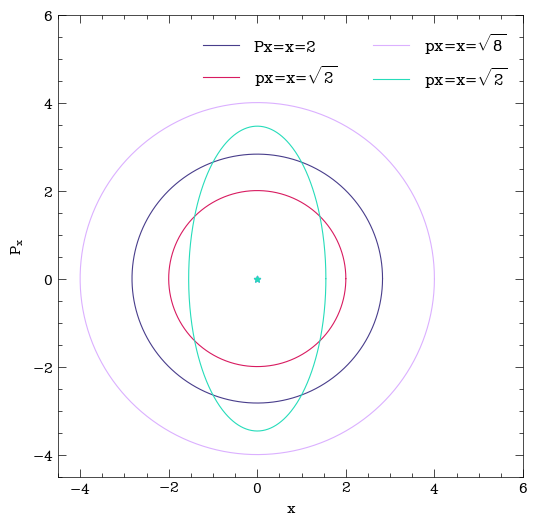

In [26]:
va.help.plot()

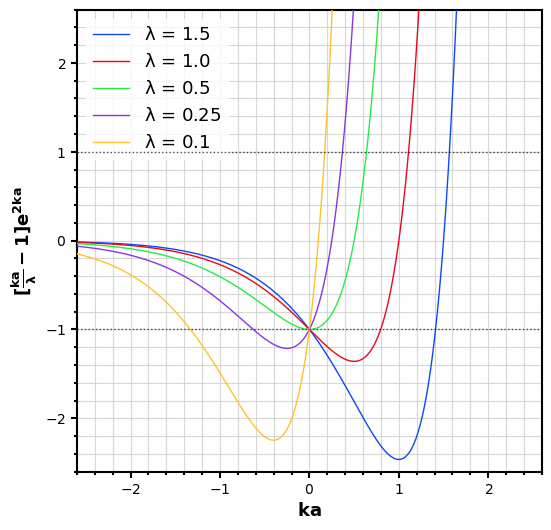

In [27]:
va.help.plot()

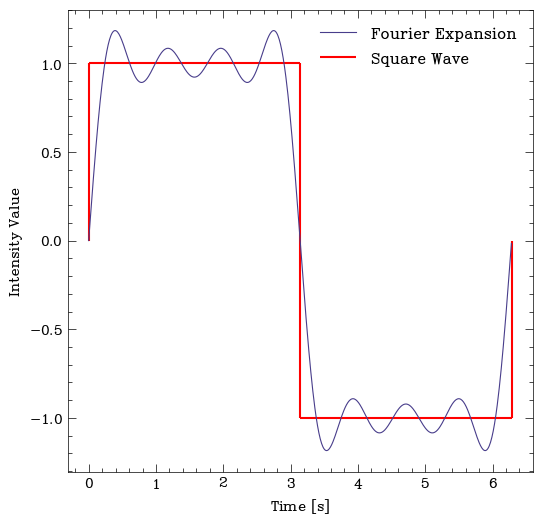

In [35]:
va.help.plot()

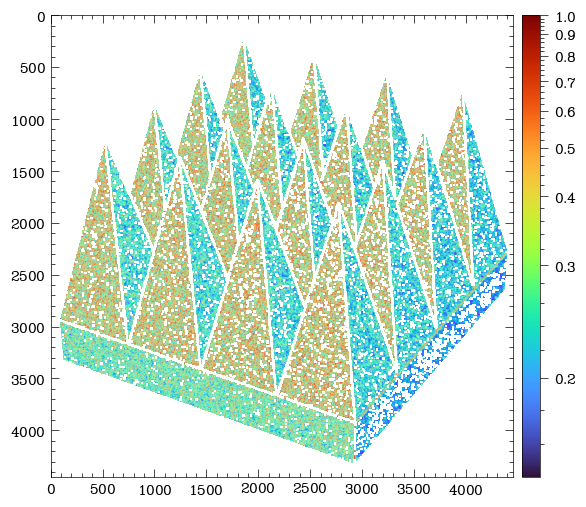

In [29]:
va.help.imshow()

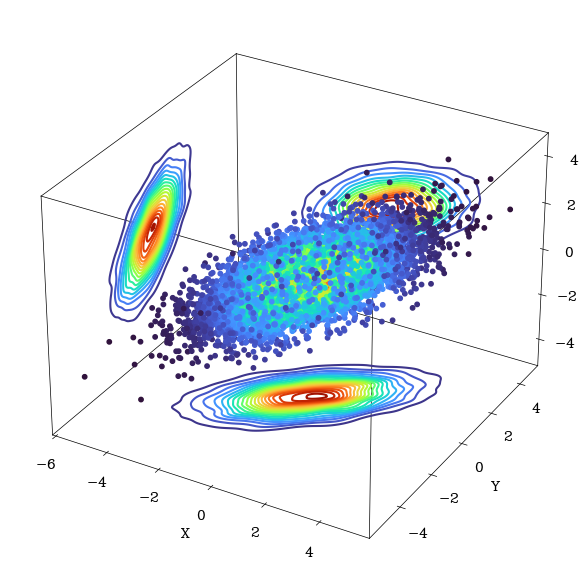

In [30]:
va.help.scatter3D()